In [2]:
from pathlib import Path
import pandas as pd
import numpy as np

from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import Ridge
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, cohen_kappa_score


# ============================================================
# Config
# ============================================================

PROJECT_NAME = "IELTS-Writing-Evals"

TEXT_COL = "essay"
SET_COL = "essay_set"
SCORE_COL = "domain1_score"

SEED = 42

# Output result
RESULT_FILENAME = "experiment1_tfidf_svr_ridge_results.csv"
PREDICTION_FILENAME = "experiment1_tfidf_svr_ridge_predictions.csv"


# ============================================================
# Find project root
# ============================================================

def find_project_root(project_name=PROJECT_NAME):
    current = Path.cwd().resolve()

    for path in [current, *current.parents]:
        if path.name == project_name:
            return path

    for path in [current, *current.parents]:
        candidate = path / project_name
        if candidate.exists() and candidate.is_dir():
            return candidate

    raise FileNotFoundError(
        f"Cannot find project root: {project_name}. "
        f"Current working directory is: {current}"
    )


PROJECT_ROOT = find_project_root()

DATA_DIR = PROJECT_ROOT / "dataset" / "asap"
BENCHMARK_DIR = PROJECT_ROOT / "benchmark_asap"
BENCHMARK_DIR.mkdir(parents=True, exist_ok=True)

train_path = DATA_DIR / "asap_train.csv"
val_path = DATA_DIR / "asap_val.csv"
test_path = DATA_DIR / "asap_test.csv"

result_path = BENCHMARK_DIR / RESULT_FILENAME
prediction_path = BENCHMARK_DIR / PREDICTION_FILENAME

print("Project root:", PROJECT_ROOT)
print("Train path:", train_path)
print("Val path:  ", val_path)
print("Test path: ", test_path)
print("Result path:", result_path)
print("Prediction path:", prediction_path)

for path in [train_path, val_path, test_path]:
    if not path.exists():
        raise FileNotFoundError(f"File not found: {path}")


# ============================================================
# Load data
# ============================================================

train_df = pd.read_csv(train_path)
val_df = pd.read_csv(val_path)
test_df = pd.read_csv(test_path)

required_cols = {TEXT_COL, SET_COL, SCORE_COL}

for name, df in [("train", train_df), ("val", val_df), ("test", test_df)]:
    missing_cols = required_cols - set(df.columns)
    if missing_cols:
        raise ValueError(f"{name}.csv missing columns: {missing_cols}")

print("\nLoaded data:")
print("Train:", train_df.shape)
print("Val:  ", val_df.shape)
print("Test: ", test_df.shape)


# ============================================================
# Metrics
# ============================================================

def clip_and_round_predictions(y_pred, min_score, max_score):
    """
    QWK cần score dạng integer/discrete.
    Model regression trả về float nên cần clip về score range rồi round.
    """
    y_pred = np.asarray(y_pred)
    y_pred = np.clip(y_pred, min_score, max_score)
    y_pred = np.rint(y_pred).astype(int)
    return y_pred


def compute_metrics(y_true, y_pred_rounded):
    qwk = cohen_kappa_score(y_true, y_pred_rounded, weights="quadratic")
    mae = mean_absolute_error(y_true, y_pred_rounded)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred_rounded))

    return {
        "qwk": qwk,
        "mae": mae,
        "rmse": rmse,
    }


# ============================================================
# Model configs
# ============================================================

model_configs = {
    "TF-IDF + Ridge": [
        {
            "model": Ridge(alpha=0.1, random_state=SEED),
            "params": {"alpha": 0.1},
        },
        {
            "model": Ridge(alpha=1.0, random_state=SEED),
            "params": {"alpha": 1.0},
        },
        {
            "model": Ridge(alpha=10.0, random_state=SEED),
            "params": {"alpha": 10.0},
        },
    ],
    "TF-IDF + SVR": [
        {
            "model": SVR(kernel="linear", C=0.1, epsilon=0.1),
            "params": {"kernel": "linear", "C": 0.1, "epsilon": 0.1},
        },
        {
            "model": SVR(kernel="linear", C=1.0, epsilon=0.1),
            "params": {"kernel": "linear", "C": 1.0, "epsilon": 0.1},
        },
        {
            "model": SVR(kernel="linear", C=10.0, epsilon=0.1),
            "params": {"kernel": "linear", "C": 10.0, "epsilon": 0.1},
        },
    ],
}


def build_pipeline(model):
    return Pipeline([
        (
            "tfidf",
            TfidfVectorizer(
                lowercase=True,
                stop_words=None,
                ngram_range=(1, 2),
                min_df=2,
                max_df=0.95,
                max_features=50000,
                sublinear_tf=True,
            )
        ),
        ("regressor", model)
    ])


# ============================================================
# Train per essay_set
# ============================================================

results = []
all_predictions = []

essay_sets = sorted(train_df[SET_COL].unique())

for essay_set in essay_sets:
    print(f"\n================ Essay set {essay_set} ================")

    train_set_df = train_df[train_df[SET_COL] == essay_set].copy()
    val_set_df = val_df[val_df[SET_COL] == essay_set].copy()
    test_set_df = test_df[test_df[SET_COL] == essay_set].copy()

    # Score range lấy từ train + val để tránh dùng test trong quá trình chọn model
    train_val_set_df = pd.concat([train_set_df, val_set_df], axis=0)

    min_score = int(train_val_set_df[SCORE_COL].min())
    max_score = int(train_val_set_df[SCORE_COL].max())

    X_train = train_set_df[TEXT_COL].astype(str)
    y_train = train_set_df[SCORE_COL].astype(int)

    X_val = val_set_df[TEXT_COL].astype(str)
    y_val = val_set_df[SCORE_COL].astype(int)

    X_train_val = train_val_set_df[TEXT_COL].astype(str)
    y_train_val = train_val_set_df[SCORE_COL].astype(int)

    X_test = test_set_df[TEXT_COL].astype(str)
    y_test = test_set_df[SCORE_COL].astype(int)

    for method_name, configs in model_configs.items():
        print(f"\nMethod: {method_name}")

        best_config = None
        best_val_qwk = -999
        best_val_metrics = None

        # ------------------------------
        # Select hyperparameters on val
        # ------------------------------
        for config in configs:
            model = config["model"]
            params = config["params"]

            pipeline = build_pipeline(model)
            pipeline.fit(X_train, y_train)

            val_pred_raw = pipeline.predict(X_val)
            val_pred = clip_and_round_predictions(
                val_pred_raw,
                min_score=min_score,
                max_score=max_score,
            )

            val_metrics = compute_metrics(y_val, val_pred)

            print(
                f"Params: {params} | "
                f"Val QWK: {val_metrics['qwk']:.4f} | "
                f"Val MAE: {val_metrics['mae']:.4f} | "
                f"Val RMSE: {val_metrics['rmse']:.4f}"
            )

            if val_metrics["qwk"] > best_val_qwk:
                best_val_qwk = val_metrics["qwk"]
                best_config = config
                best_val_metrics = val_metrics

        # ------------------------------
        # Retrain best model on train + val
        # ------------------------------
        final_pipeline = build_pipeline(best_config["model"])
        final_pipeline.fit(X_train_val, y_train_val)

        # ------------------------------
        # Evaluate on test
        # ------------------------------
        test_pred_raw = final_pipeline.predict(X_test)
        test_pred = clip_and_round_predictions(
            test_pred_raw,
            min_score=min_score,
            max_score=max_score,
        )

        test_metrics = compute_metrics(y_test, test_pred)

        print(
            f"Best params: {best_config['params']} | "
            f"Test QWK: {test_metrics['qwk']:.4f} | "
            f"Test MAE: {test_metrics['mae']:.4f} | "
            f"Test RMSE: {test_metrics['rmse']:.4f}"
        )

        result_row = {
            "essay_set": essay_set,
            "method": method_name,
            "best_params": str(best_config["params"]),
            "score_min": min_score,
            "score_max": max_score,
            "train_size": len(train_set_df),
            "val_size": len(val_set_df),
            "test_size": len(test_set_df),
            "val_qwk": best_val_metrics["qwk"],
            "val_mae": best_val_metrics["mae"],
            "val_rmse": best_val_metrics["rmse"],
            "test_qwk": test_metrics["qwk"],
            "test_mae": test_metrics["mae"],
            "test_rmse": test_metrics["rmse"],
        }

        results.append(result_row)

        pred_df = test_set_df.copy()
        pred_df["method"] = method_name
        pred_df["prediction_raw"] = test_pred_raw
        pred_df["prediction_rounded"] = test_pred
        pred_df["score_min"] = min_score
        pred_df["score_max"] = max_score

        all_predictions.append(pred_df)


# ============================================================
# Save results
# ============================================================

results_df = pd.DataFrame(results)

# Average across essay sets for each method
average_rows = []

for method_name, method_df in results_df.groupby("method"):
    average_rows.append({
        "essay_set": "average",
        "method": method_name,
        "best_params": "-",
        "score_min": "-",
        "score_max": "-",
        "train_size": method_df["train_size"].sum(),
        "val_size": method_df["val_size"].sum(),
        "test_size": method_df["test_size"].sum(),
        "val_qwk": method_df["val_qwk"].mean(),
        "val_mae": method_df["val_mae"].mean(),
        "val_rmse": method_df["val_rmse"].mean(),
        "test_qwk": method_df["test_qwk"].mean(),
        "test_mae": method_df["test_mae"].mean(),
        "test_rmse": method_df["test_rmse"].mean(),
    })

average_df = pd.DataFrame(average_rows)

final_results_df = pd.concat([results_df, average_df], axis=0, ignore_index=True)

predictions_df = pd.concat(all_predictions, axis=0, ignore_index=True)

final_results_df.to_csv(result_path, index=False)
predictions_df.to_csv(prediction_path, index=False)

print("\n================ Final Results ================")
display(final_results_df)

print("\nSaved result file:")
print(result_path)

print("\nSaved prediction file:")
print(prediction_path)

Project root: D:\CS222\ielts\IELTS-Writing-Evals
Train path: D:\CS222\ielts\IELTS-Writing-Evals\dataset\asap\asap_train.csv
Val path:   D:\CS222\ielts\IELTS-Writing-Evals\dataset\asap\asap_val.csv
Test path:  D:\CS222\ielts\IELTS-Writing-Evals\dataset\asap\asap_test.csv
Result path: D:\CS222\ielts\IELTS-Writing-Evals\benchmark_asap\experiment1_tfidf_svr_ridge_results.csv
Prediction path: D:\CS222\ielts\IELTS-Writing-Evals\benchmark_asap\experiment1_tfidf_svr_ridge_predictions.csv

Loaded data:
Train: (9084, 5)
Val:   (1296, 5)
Test:  (2596, 5)

================ Essay set 1 ================

Method: TF-IDF + Ridge
Params: {'alpha': 0.1} | Val QWK: 0.7031 | Val MAE: 0.7556 | Val RMSE: 1.0435
Params: {'alpha': 1.0} | Val QWK: 0.6596 | Val MAE: 0.7333 | Val RMSE: 1.0541
Params: {'alpha': 10.0} | Val QWK: 0.3758 | Val MAE: 0.8722 | Val RMSE: 1.2974
Best params: {'alpha': 0.1} | Test QWK: 0.7086 | Test MAE: 0.7127 | Test RMSE: 1.0168

Method: TF-IDF + SVR
Params: {'kernel': 'linear', 'C': 0.

,essay_set,method,best_params,score_min,score_max,train_size,val_size,test_size,val_qwk,val_mae,val_rmse,test_qwk,test_mae,test_rmse
0,1,TF-IDF + Ridge,{'alpha': 0.1},2,12,1248,180,355,0.703090,0.755556,1.043498,0.708568,0.712676,1.016761
1,1,TF-IDF + SVR,"{'kernel': 'linear', 'C': 10.0, 'epsilon': 0.1}",2,12,1248,180,355,0.715628,0.744444,1.032796,0.712063,0.721127,1.018145
2,2,TF-IDF + Ridge,{'alpha': 0.1},1,6,1260,180,360,0.596285,0.372222,0.628048,0.578347,0.355556,0.619139
3,2,TF-IDF + SVR,"{'kernel': 'linear', 'C': 10.0, 'epsilon': 0.1}",1,6,1260,180,360,0.597084,0.366667,0.623610,0.578819,0.355556,0.619139
4,3,TF-IDF + Ridge,{'alpha': 0.1},0,3,1208,173,345,0.505337,0.462428,0.721271,0.551877,0.440580,0.689465
5,3,TF-IDF + SVR,"{'kernel': 'linear', 'C': 1.0, 'epsilon': 0.1}",0,3,1208,173,345,0.526059,0.445087,0.692653,0.564454,0.426087,0.670280
6,4,TF-IDF + Ridge,{'alpha': 0.1},0,3,1239,177,354,0.734644,0.389831,0.624364,0.752765,0.358757,0.617540
7,4,TF-IDF + SVR,"{'kernel': 'linear', 'C': 1.0, 'epsilon': 0.1}",0,3,1239,177,354,0.746681,0.367232,0.605996,0.746070,0.364407,0.622098
8,5,TF-IDF + Ridge,{'alpha': 0.1},0,4,1263,180,362,0.692794,0.405556,0.670820,0.730269,0.414365,0.656460
9,5,TF-IDF + SVR,"{'kernel': 'linear', 'C': 10.0, 'epsilon': 0.1}",0,4,1263,180,362,0.676894,0.422222,0.691215,0.737185,0.403315,0.647989



Saved result file:
D:\CS222\ielts\IELTS-Writing-Evals\benchmark_asap\experiment1_tfidf_svr_ridge_results.csv

Saved prediction file:
D:\CS222\ielts\IELTS-Writing-Evals\benchmark_asap\experiment1_tfidf_svr_ridge_predictions.csv


Project root: D:\CS222\ielts\IELTS-Writing-Evals
Result path: D:\CS222\ielts\IELTS-Writing-Evals\benchmark_results\ASAP\experiment1_tfidf_svr_ridge_results.csv
Result exists: True

Per essay set results:


,essay_set,method,best_params,score_min,score_max,train_size,val_size,test_size,val_qwk,val_mae,val_rmse,test_qwk,test_mae,test_rmse
0,1,TF-IDF + Ridge,{'alpha': 0.1},2,12,1248,180,355,0.703090,0.755556,1.043498,0.708568,0.712676,1.016761
1,1,TF-IDF + SVR,"{'kernel': 'linear', 'C': 10.0, 'epsilon': 0.1}",2,12,1248,180,355,0.715628,0.744444,1.032796,0.712063,0.721127,1.018145
2,2,TF-IDF + Ridge,{'alpha': 0.1},1,6,1260,180,360,0.596285,0.372222,0.628048,0.578347,0.355556,0.619139
3,2,TF-IDF + SVR,"{'kernel': 'linear', 'C': 10.0, 'epsilon': 0.1}",1,6,1260,180,360,0.597084,0.366667,0.623610,0.578819,0.355556,0.619139
4,3,TF-IDF + Ridge,{'alpha': 0.1},0,3,1208,173,345,0.505337,0.462428,0.721271,0.551877,0.440580,0.689465
5,3,TF-IDF + SVR,"{'kernel': 'linear', 'C': 1.0, 'epsilon': 0.1}",0,3,1208,173,345,0.526059,0.445087,0.692653,0.564454,0.426087,0.670280
6,4,TF-IDF + Ridge,{'alpha': 0.1},0,3,1239,177,354,0.734644,0.389831,0.624364,0.752765,0.358757,0.617540
7,4,TF-IDF + SVR,"{'kernel': 'linear', 'C': 1.0, 'epsilon': 0.1}",0,3,1239,177,354,0.746681,0.367232,0.605996,0.746070,0.364407,0.622098
8,5,TF-IDF + Ridge,{'alpha': 0.1},0,4,1263,180,362,0.692794,0.405556,0.670820,0.730269,0.414365,0.656460
9,5,TF-IDF + SVR,"{'kernel': 'linear', 'C': 10.0, 'epsilon': 0.1}",0,4,1263,180,362,0.676894,0.422222,0.691215,0.737185,0.403315,0.647989



Average results:


,essay_set,method,best_params,score_min,score_max,train_size,val_size,test_size,val_qwk,val_mae,val_rmse,test_qwk,test_mae,test_rmse
16,average,TF-IDF + Ridge,-,-,-,9084,1296,2596,0.659708,1.010888,1.360185,0.667099,1.057893,1.448457
17,average,TF-IDF + SVR,-,-,-,9084,1296,2596,0.662570,1.014734,1.363456,0.670000,1.056965,1.448098


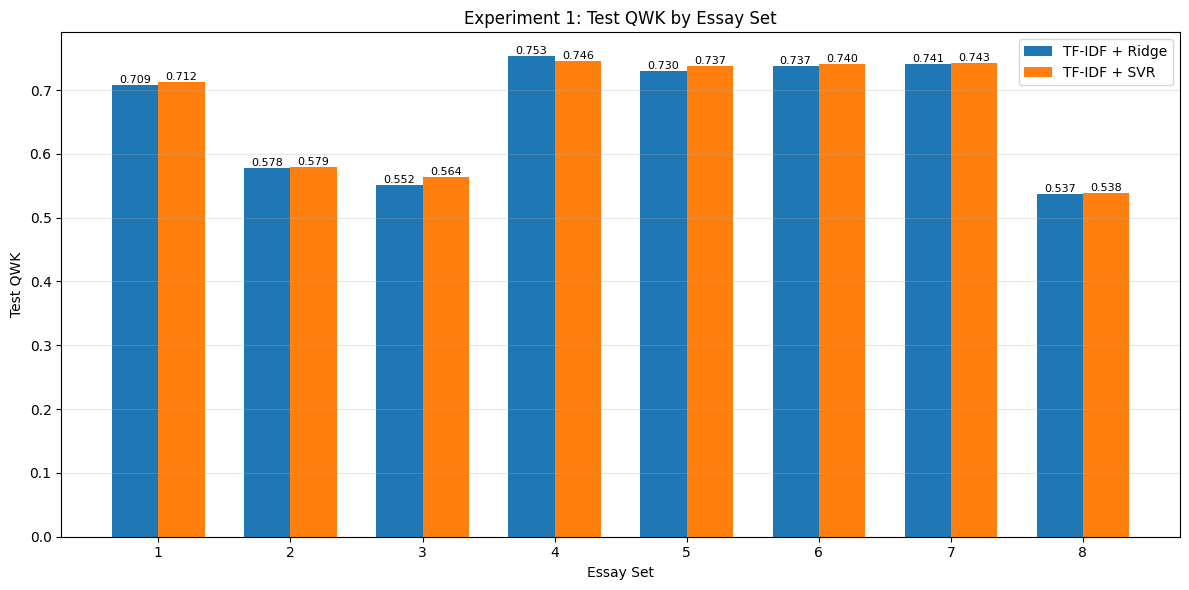

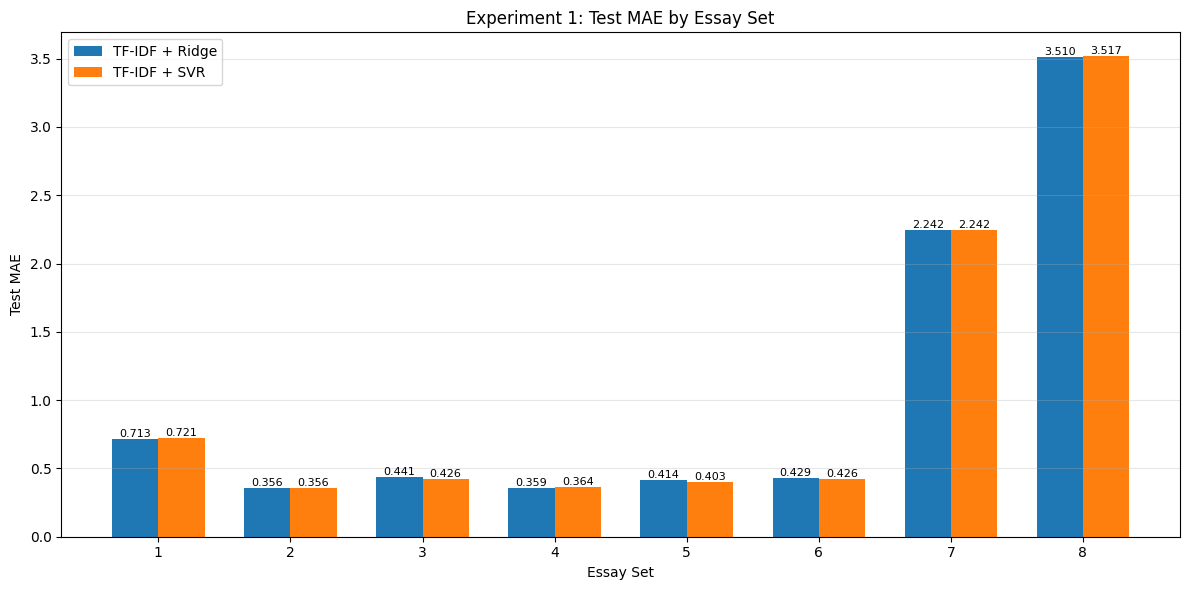

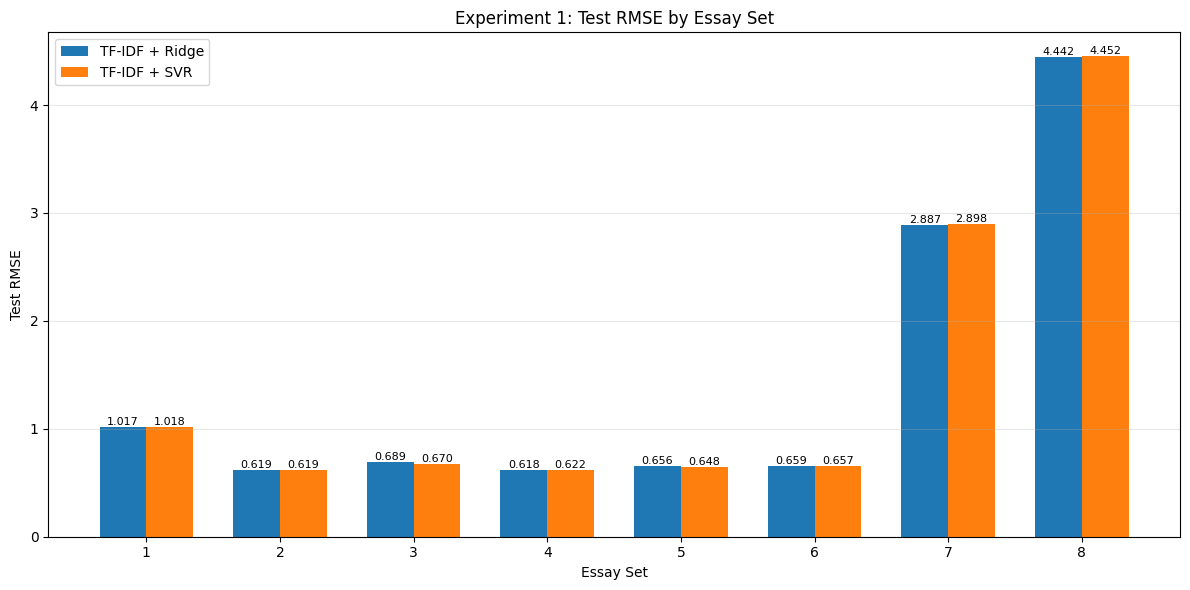


Average summary:


,Method,Avg Test QWK,Avg Test MAE,Avg Test RMSE
16,TF-IDF + Ridge,0.6671,1.0579,1.4485
17,TF-IDF + SVR,0.6700,1.0570,1.4481


In [5]:
import matplotlib.pyplot as plt

# ============================================================
# Path config
# ============================================================

PROJECT_NAME = "IELTS-Writing-Evals"

def find_project_root(project_name=PROJECT_NAME):
    current = Path.cwd().resolve()

    for path in [current, *current.parents]:
        if path.name == project_name:
            return path

    for path in [current, *current.parents]:
        candidate = path / project_name
        if candidate.exists() and candidate.is_dir():
            return candidate

    raise FileNotFoundError(
        f"Cannot find project root: {project_name}. "
        f"Current working directory is: {current}"
    )

PROJECT_ROOT = find_project_root()

RESULT_DIR = PROJECT_ROOT / "benchmark_results" / "ASAP"
result_path = RESULT_DIR / "experiment1_tfidf_svr_ridge_results.csv"

print("Project root:", PROJECT_ROOT)
print("Result path:", result_path)
print("Result exists:", result_path.exists())

if not result_path.exists():
    raise FileNotFoundError(f"Result file not found: {result_path}")

# ============================================================
# Load results
# ============================================================

results_df = pd.read_csv(result_path)

set_results_df = results_df[results_df["essay_set"].astype(str) != "average"].copy()
avg_results_df = results_df[results_df["essay_set"].astype(str) == "average"].copy()

set_results_df["essay_set"] = set_results_df["essay_set"].astype(int)

print("\nPer essay set results:")
display(set_results_df)

print("\nAverage results:")
display(avg_results_df)

# ============================================================
# Plot helper
# ============================================================

def plot_metric_by_essay_set(
    df,
    metric_col,
    ylabel,
    title,
):
    methods = list(df["method"].unique())
    essay_sets = sorted(df["essay_set"].unique())

    x = np.arange(len(essay_sets))
    width = 0.35

    plt.figure(figsize=(12, 6))

    for i, method in enumerate(methods):
        method_df = df[df["method"] == method].sort_values("essay_set")
        values = method_df[metric_col].values

        offset = (i - (len(methods) - 1) / 2) * width

        bars = plt.bar(
            x + offset,
            values,
            width,
            label=method,
        )

        for bar in bars:
            height = bar.get_height()
            plt.text(
                bar.get_x() + bar.get_width() / 2,
                height,
                f"{height:.3f}",
                ha="center",
                va="bottom",
                fontsize=8,
            )

    plt.xticks(x, essay_sets)
    plt.xlabel("Essay Set")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

# ============================================================
# Plot Test QWK / MAE / RMSE
# ============================================================

plot_metric_by_essay_set(
    df=set_results_df,
    metric_col="test_qwk",
    ylabel="Test QWK",
    title="Experiment 1: Test QWK by Essay Set",
)

plot_metric_by_essay_set(
    df=set_results_df,
    metric_col="test_mae",
    ylabel="Test MAE",
    title="Experiment 1: Test MAE by Essay Set",
)

plot_metric_by_essay_set(
    df=set_results_df,
    metric_col="test_rmse",
    ylabel="Test RMSE",
    title="Experiment 1: Test RMSE by Essay Set",
)

# ============================================================
# Average summary table
# ============================================================

summary_cols = [
    "method",
    "test_qwk",
    "test_mae",
    "test_rmse",
]

avg_summary = avg_results_df[summary_cols].copy()

avg_summary = avg_summary.rename(columns={
    "method": "Method",
    "test_qwk": "Avg Test QWK",
    "test_mae": "Avg Test MAE",
    "test_rmse": "Avg Test RMSE",
})

avg_summary["Avg Test QWK"] = avg_summary["Avg Test QWK"].astype(float).round(4)
avg_summary["Avg Test MAE"] = avg_summary["Avg Test MAE"].astype(float).round(4)
avg_summary["Avg Test RMSE"] = avg_summary["Avg Test RMSE"].astype(float).round(4)

print("\nAverage summary:")
display(avg_summary)